all imports needed

In [3]:
import json
import torch
import matplotlib.pyplot as plt
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

Load Resnet18 model and preprocess weights.
Load images and resize and normalize according to ImageNet standards.

In [27]:
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()
preprocess = weights.transforms()

base_path = r"C:/Users/vilma/Machine-learning/Assignments/Lab2/Images/"

image_files = {
    "elephant": "img_african_elephant.jpg",
    "hippo": "img_hippo.jpg",
    "firetruck": "img_firetruck.jpg",
    "ambulance": "img_ambulance.jpg",
    "guitar": "img_acoustic_guitar.jpg",
    "violin": "img_violin.jpg"
}

images = {name: decode_image(base_path + file).float()/255.0 for name, file in image_files.items()}

inputs = {name: preprocess(img) for name, img in images.items()}

Generate batch and extract CAM.

In [28]:
batch = torch.stack(list(inputs.values()))
cams_layer4 = {}
with LayerCAM(model, target_layer="layer4") as cam_extractor:
    outputs = {}
    for name, img in zip(inputs.keys(), batch):
        img = img.unsqueeze(0)
        output = model(img)
        class_idx = output.argmax(dim=1).item()
        cam = cam_extractor(class_idx, output)[0]
        cams_layer4[name] = cam
        outputs[name] = output

Show images function

In [29]:
def show_image(img):
    plt.imshow(img)
    plt.axis('off')
    plt.title(name)
    plt.tight_layout()
    plt.show()

show CAM images

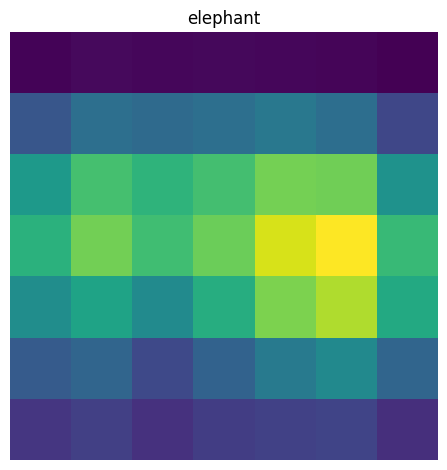

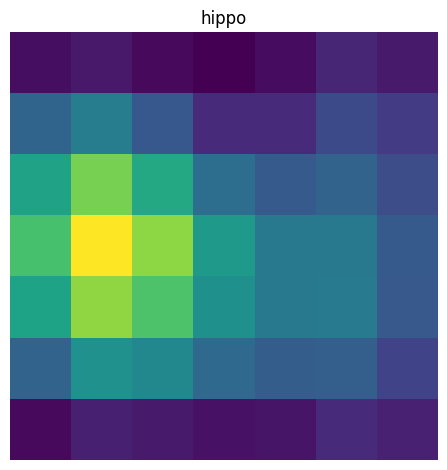

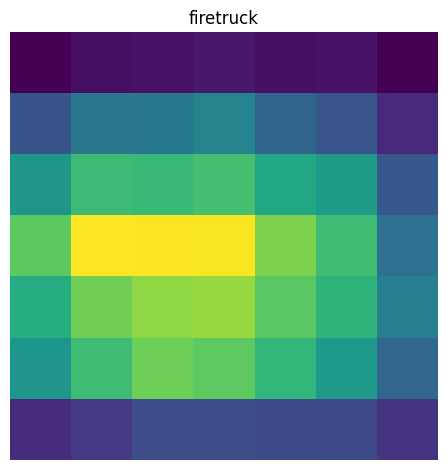

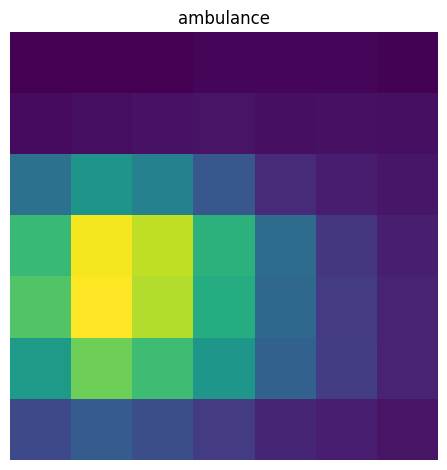

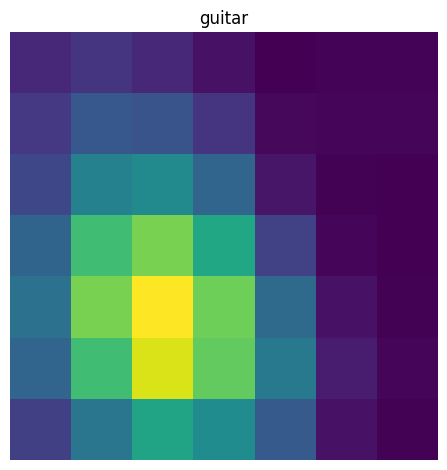

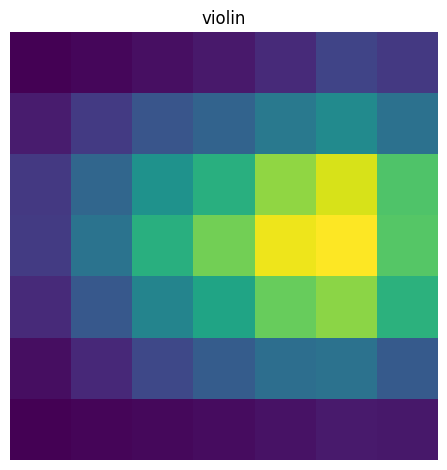

In [30]:
for name, cam in cams_layer4.items():
    show_image(cam.squeeze(0).detach().numpy())

Show results with overlay_mask

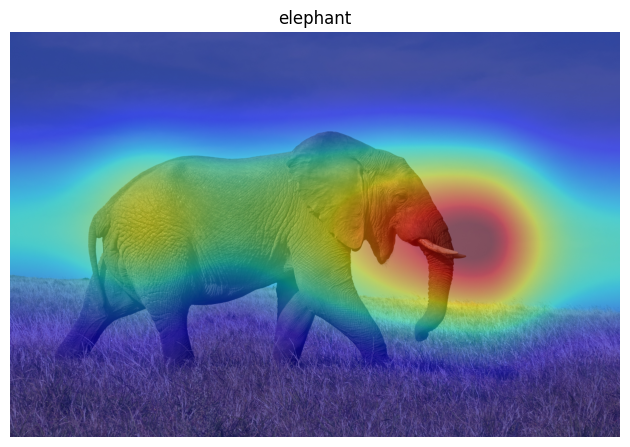

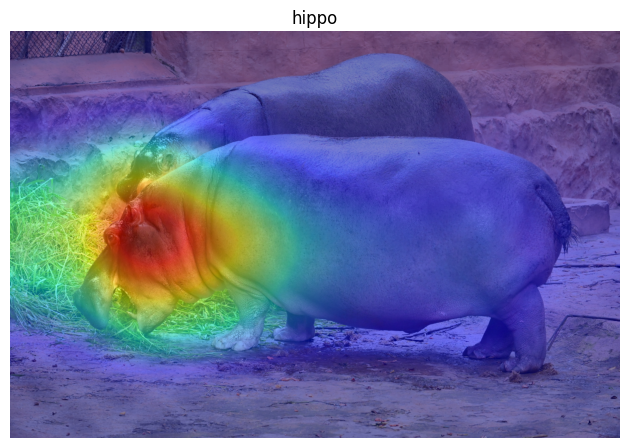

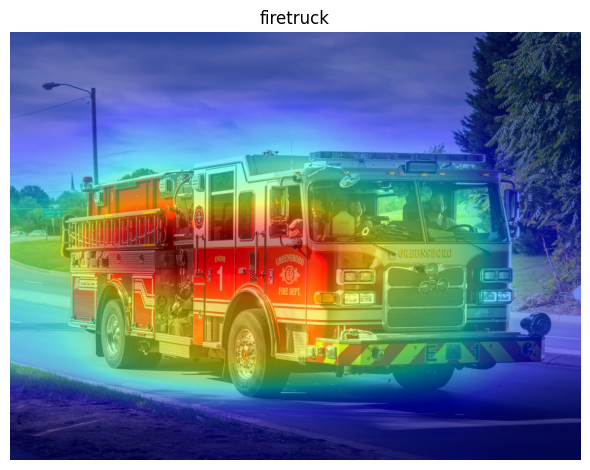

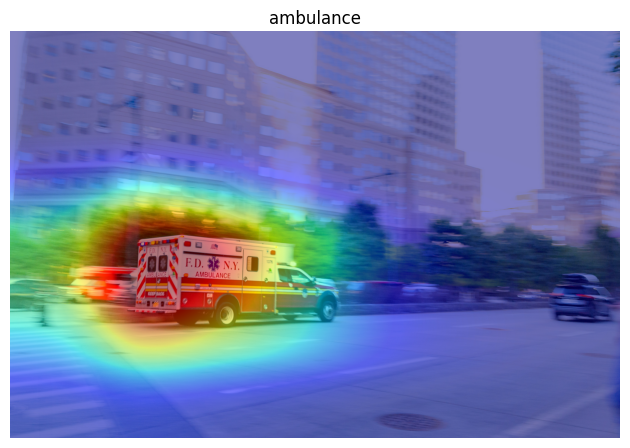

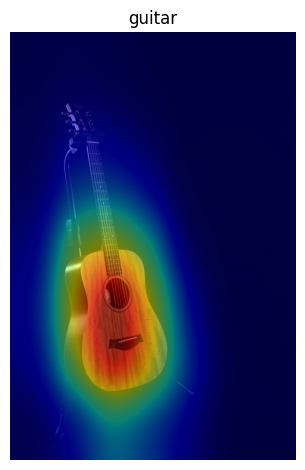

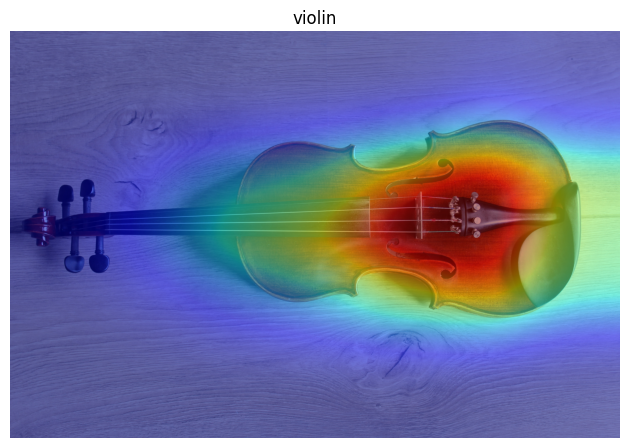

In [31]:
results = {}
for name in images:
    results[name] = overlay_mask(
        to_pil_image(images[name]),
        to_pil_image(cams_layer4[name].squeeze(0), mode='F'),
        alpha=0.5
    )

for name, res in results.items():
    show_image(res)

Open ImageNet class index

In [32]:
with open("C:\\Users\\vilma\\Machine-learning\\Assignments\\Lab2\\imagenet_class_index.json", 'r') as f:
    class_index = json.load(f)

Predict class function

In [33]:
def predict_class(probs, class_index):
    top_idx = int(probs.argmax())
    synset_id, class_name = class_index[str(top_idx)]

    return{
        "class_index": top_idx,
        "class_id": synset_id,
        "class_name": class_name,
        "confidence": float(probs[top_idx].item())
    }

run the prediction function and print results

In [34]:
predictions = []
for name, output in outputs.items():
    probs = output.softmax(dim=1).squeeze(0)
    predictions.append(predict_class(probs, class_index))

print(predictions)

[{'class_index': 386, 'class_id': 'n02504458', 'class_name': 'African_elephant', 'confidence': 0.5068271160125732}, {'class_index': 344, 'class_id': 'n02398521', 'class_name': 'hippopotamus', 'confidence': 0.999891996383667}, {'class_index': 555, 'class_id': 'n03345487', 'class_name': 'fire_engine', 'confidence': 0.9979885816574097}, {'class_index': 407, 'class_id': 'n02701002', 'class_name': 'ambulance', 'confidence': 0.9393348693847656}, {'class_index': 402, 'class_id': 'n02676566', 'class_name': 'acoustic_guitar', 'confidence': 0.9951629638671875}, {'class_index': 889, 'class_id': 'n04536866', 'class_name': 'violin', 'confidence': 0.9552302956581116}]


Running the Elephant img and the guitar img through early and middle layers.

In [35]:
selected_positives = ["elephant", "guitar"]
target_layers = ["layer1", "layer2", "layer3", "layer4"]
cams_all_layers = {}

for layer in target_layers:
    cams_all_layers[layer] = {}

    with LayerCAM(model, target_layer=layer) as cam_extractor:
        for name in selected_positives:
            img = inputs[name].unsqueeze(0)
            output = model(img)
            class_idx = output.argmax(dim=1).item()
            cam = cam_extractor(class_idx, output)[0]
            cams_all_layers[layer][name] = cam



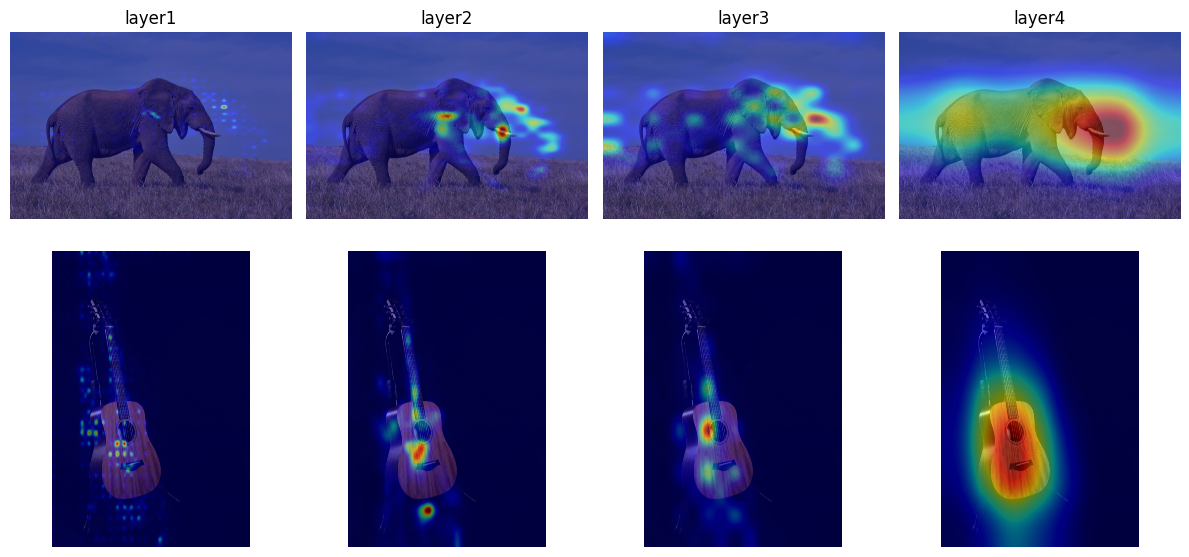

In [36]:

fig, axes = plt.subplots(len(selected_positives), len(target_layers), figsize=(12, 6))

for i, name in enumerate(selected_positives):
    for j, layer in enumerate(target_layers):
        cam = cams_all_layers[layer][name]
        overlay = overlay_mask(to_pil_image(images[name]), to_pil_image(cam.squeeze(0), mode='F'), alpha=0.5)
        axes[i, j].imshow(overlay)
        axes[i, j].axis('off')

        if i == 0:
            axes[i, j].set_title(layer)

        if j == 0:
            axes[i, j].set_ylabel(name)

plt.tight_layout()
plt.show()

A class that does not exist in the ImageNet index.

In [37]:
image_files["statue"] = "img_statue.jpg"

images = {name: decode_image(base_path + file).float()/255.0 for name, file in image_files.items()}
inputs = {name: preprocess(img) for name, img in images.items()}

img = inputs["statue"].unsqueeze(0)
with LayerCAM(model, target_layer="layer4") as cam_extractor:
    output = model(img)
    class_idx = output.argmax(dim=1).item()
    cam = cam_extractor(class_idx, output)[0]
    cams_layer4["statue"] = cam
    outputs["statue"] = output

probs = output.softmax(dim=1).squeeze(0)
pred = predict_class(probs, class_index)
print(pred)

{'class_index': 708, 'class_id': 'n03903868', 'class_name': 'pedestal', 'confidence': 0.4729427993297577}


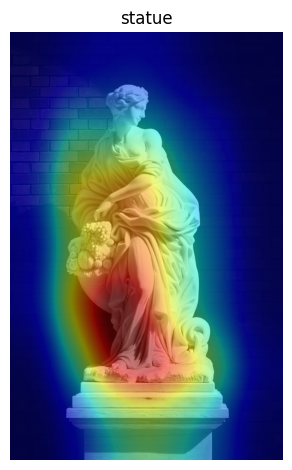

In [38]:
result = {}
result["statue"] = overlay_mask(to_pil_image(images["statue"]), to_pil_image(cams_layer4["statue"].squeeze(0), mode='F'), alpha=0.5)

for name, pred in result.items():
    show_image(result[name])